In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from ucimlrepo import fetch_ucirepo

In [58]:
warnings.filterwarnings('ignore')

In [ ]:
try:
    print("Veri API'den")
    heart_disease = fetch_ucirepo(id=45)
    X = heart_disease.data.features
    y = heart_disease.data.targets
    df = pd.concat([X, y], axis=1)

    if 'num' in df.columns:
        df.rename(columns={'num': 'diagnosis'}, inplace=True)
    print("Veri APIden yüklendi")
except Exception as e:
    print("API Hatası:", e)
    print("Veri lokalden yükleniyor")
    df = pd.read_csv('./data/heart_disease.csv')


Veri API'den çekiliyor...
API Hatası: Error connecting to server
Veri lokalden yükleniyor


In [60]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


## Değişkenler

age → yaş

sex → cinsiyet (0:kadın 1: erkek)

cp = chest pain type (4 values) → göğüs ağrısı tipi (4 farklı değer)

trestbps = resting blood pressure → dinlenme halindeki kan basıncı

chol = serum cholestoral in mg/dl → serum kolesterolü (mg/dl cinsinden)

fbs = fasting blood sugar > 120 mg/dl → açlık kan şekeri > 120 mg/dl

restecg = resting electrocardiographic results (values 0,1,2) → dinlenme elektrokardiyografi sonuçları (0, 1, 2 değerleri)

thalach = maximum heart rate achieved → ulaşılan maksimum kalp atış hızı

exang = exercise induced angina → egzersize bağlı anjina (göğüs ağrısı)

oldpeak = ST depression induced by exercise relative to rest → oldpeak = egzersiz sırasında, dinlenmeye göre oluşan ST çökmesi

slope = the slope of the peak exercise ST segment → egzersiz sırasında ST segmentinin eğimi

ca = number of major vessels (0-3) colored by flourosopy → floroskopi ile boyanan ana damar sayısı (0–3 arası)

thal = thal: 0 = normal; 1 = fixed defect; 2 = reversable defect → thal: 0 = normal; 1 = sabit kusur; 2 = geri döndürülebilir kusur

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6   restecg    303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         303 non-null    object 
 12  thal       303 non-null    object 
 13  diagnosis  303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [62]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'diagnosis'],
      dtype='object')

In [63]:
# 'ca' ve 'thal' kolonlarında '?' var, tam karar verilememiş ya da düzgün ölçülememiştir diye düşündüm ve NaN'a çevirip sayısal hale getirdim
if df['ca'].dtype == 'object':
    df['ca'] = pd.to_numeric(df['ca'].replace('?', np.nan), errors='coerce')
if df['thal'].dtype == 'object':
    df['thal'] = pd.to_numeric(df['thal'].replace('?', np.nan), errors='coerce')


# Tıbbi veri setlerinde en sık görülen değer genelde en güvenli tahminmiş o yüzden ortalama yerine mod tercih ettim
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])   
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# 'diagnosis' kolonunu 0 (Sağlıklı) ve 1 (Hasta) olarak binarye çevirdim, class imbalance dolayısıyla 0 ve 1 olarak kalması daha iyi olur diye düşündüm
df['target'] = df['diagnosis'].apply(lambda x: 1 if x > 0 else 0)
df.drop(columns=['diagnosis'], inplace=True)

print("Son Olarak Veri Tipleri:")
display(df.dtypes)

print("\nEksik Veri (NaN) Sayıları:")
display(df.isnull().sum())

Son Olarak Veri Tipleri:


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


Eksik Veri (NaN) Sayıları:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

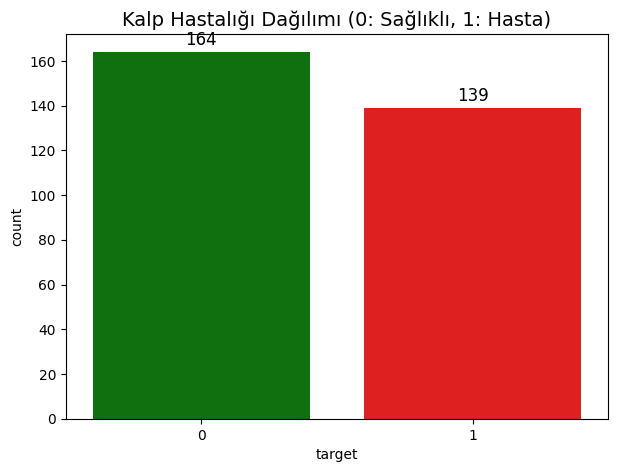

In [64]:
# Kalp Hastalığı Sınıf Dağılımı (yeşil = Sağlıklı, kırmızı = Hasta)
palette = {0: "green", 1: "red"}

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df,
    x="target",
    order=[0, 1],
    hue="target",
    palette=palette,
    legend=False
)
plt.title("Kalp Hastalığı Dağılımı (0: Sağlıklı, 1: Hasta)", fontsize=14)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="baseline", fontsize=12, color="black",
        xytext=(0, 5), textcoords="offset points"
    )

plt.show()

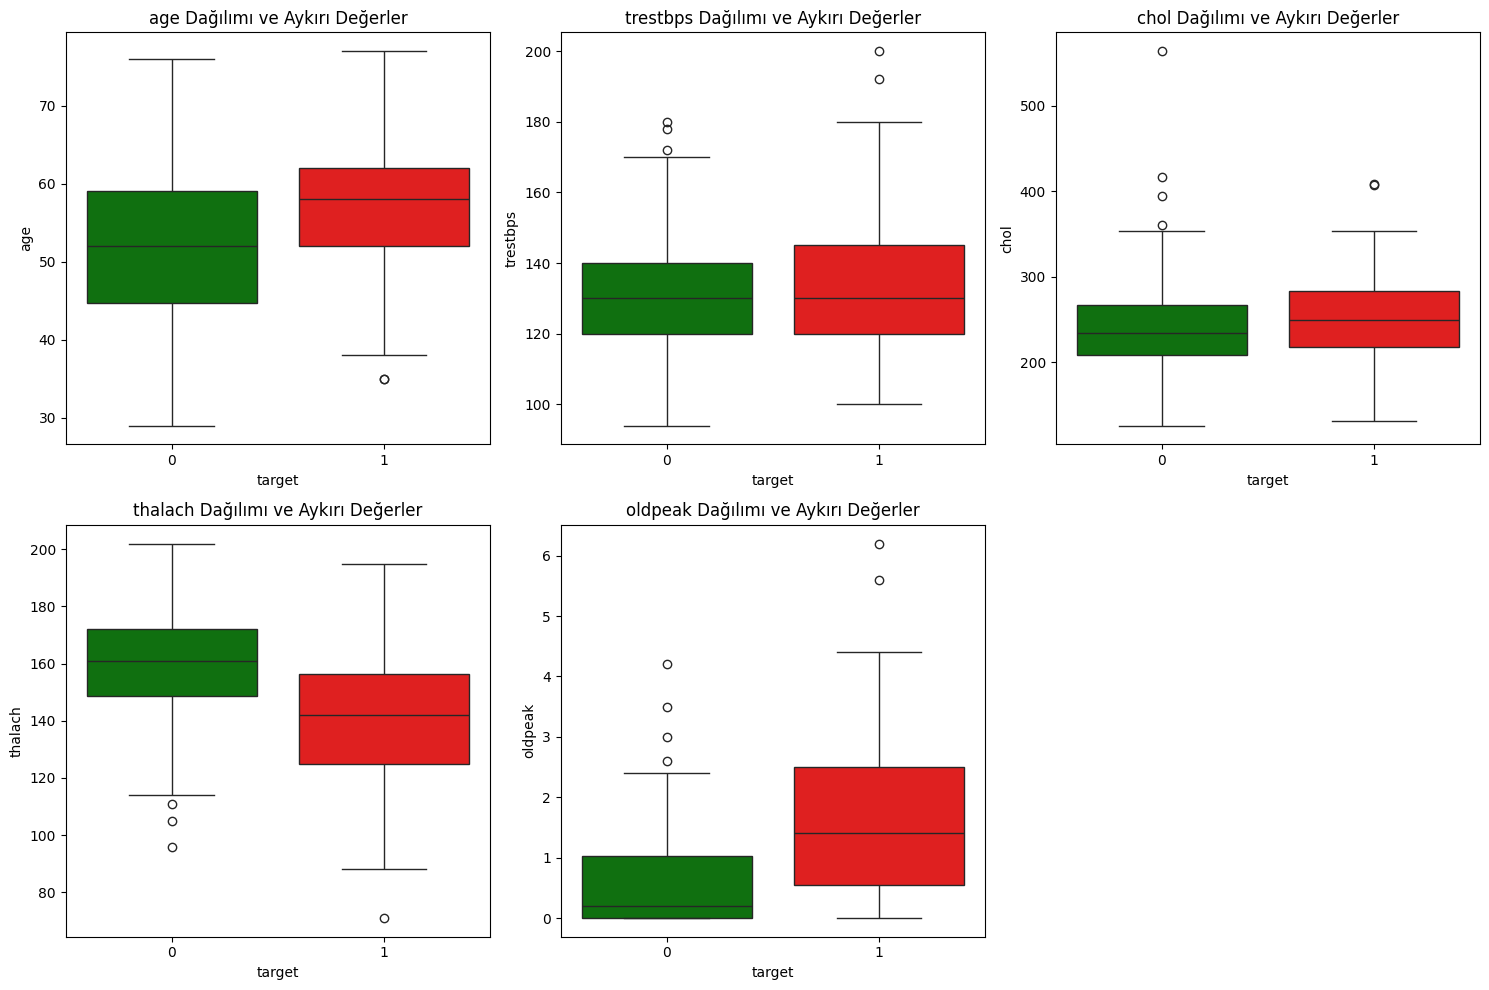

In [65]:
# Sayısal Değişkenlerde Outlier Var mı? (Boxplot), veri seti küçük olduğu için tek tek bakmak istedim, outlier'lar var gibi görünüyor
# tıbbi veri setlerinde outlier'lar genelde gerçek hastaları temsil ediyormuş, bu yüzden onları kaldırmamak daha iyi olabilir diye düşündüm
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=df,
        x='target',
        y=col,
        order=[0, 1],
        hue='target',
        palette=palette,
    )
    plt.title(f'{col} Dağılımı ve Aykırı Değerler')
plt.tight_layout()
plt.show()

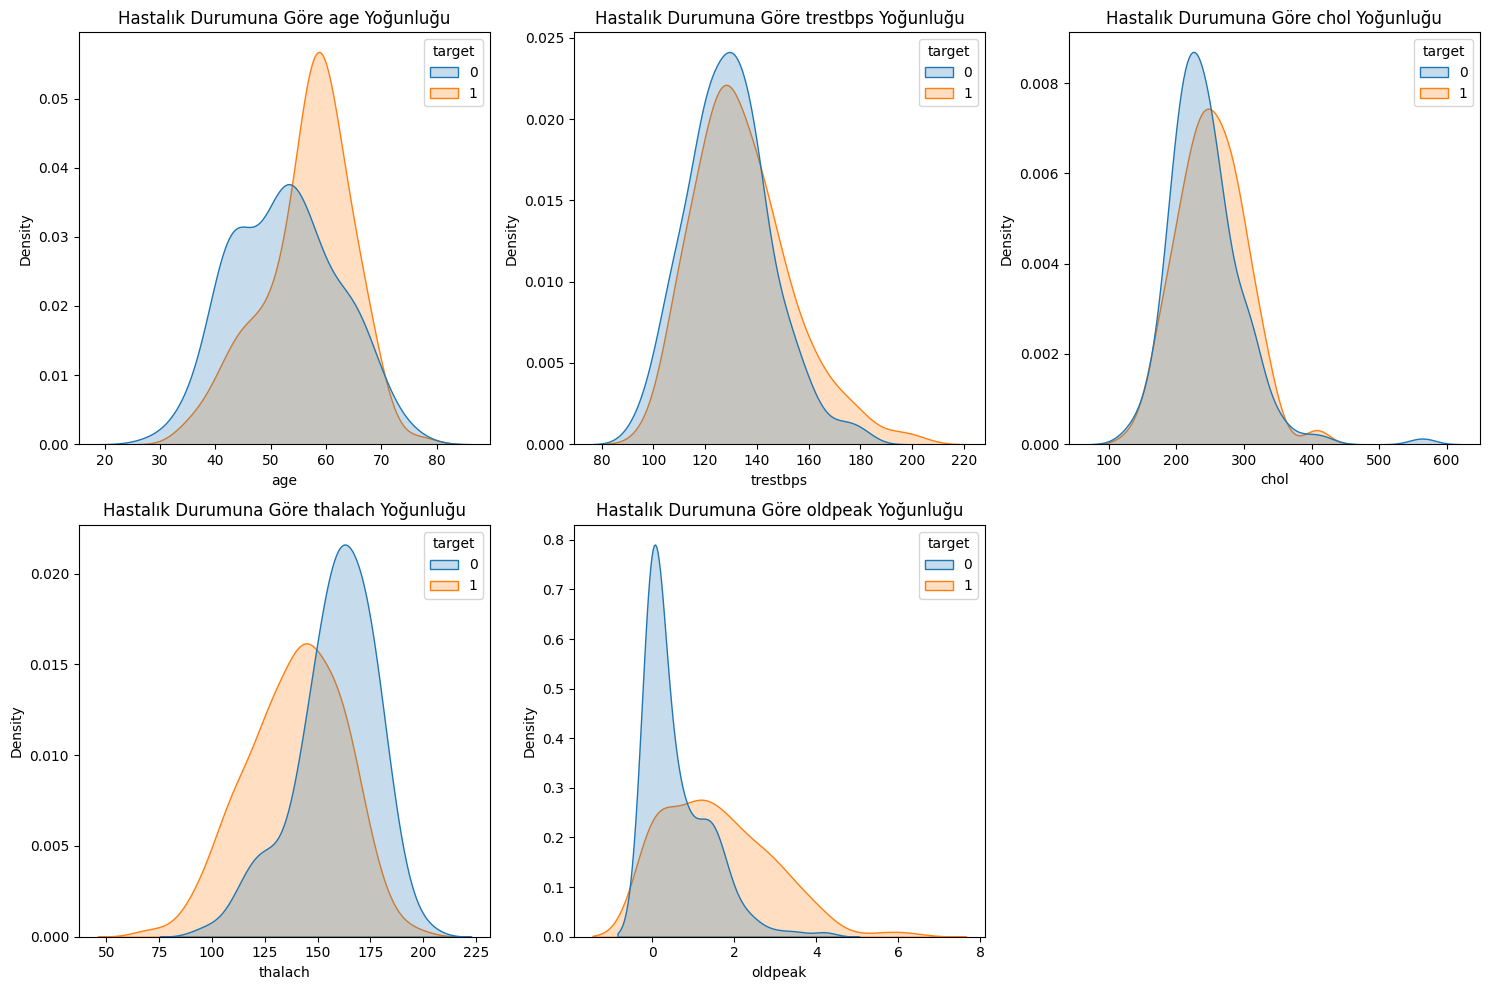

In [ ]:
# Sayısal Değişkenlerin Hastalık Durumuna Göre Yoğunluk (KDE) Dağılımları
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df, x=col, hue='target', fill=True, common_norm=False)
    plt.title(f'Hastalık Durumuna Göre {col} Yoğunluğu')
plt.tight_layout()
plt.show()

#### hasta olanların thalach değeri daha düşük, sağlıklılarda oldpeak daha düşük ve genelde yaş arttıkça hastalık artmış

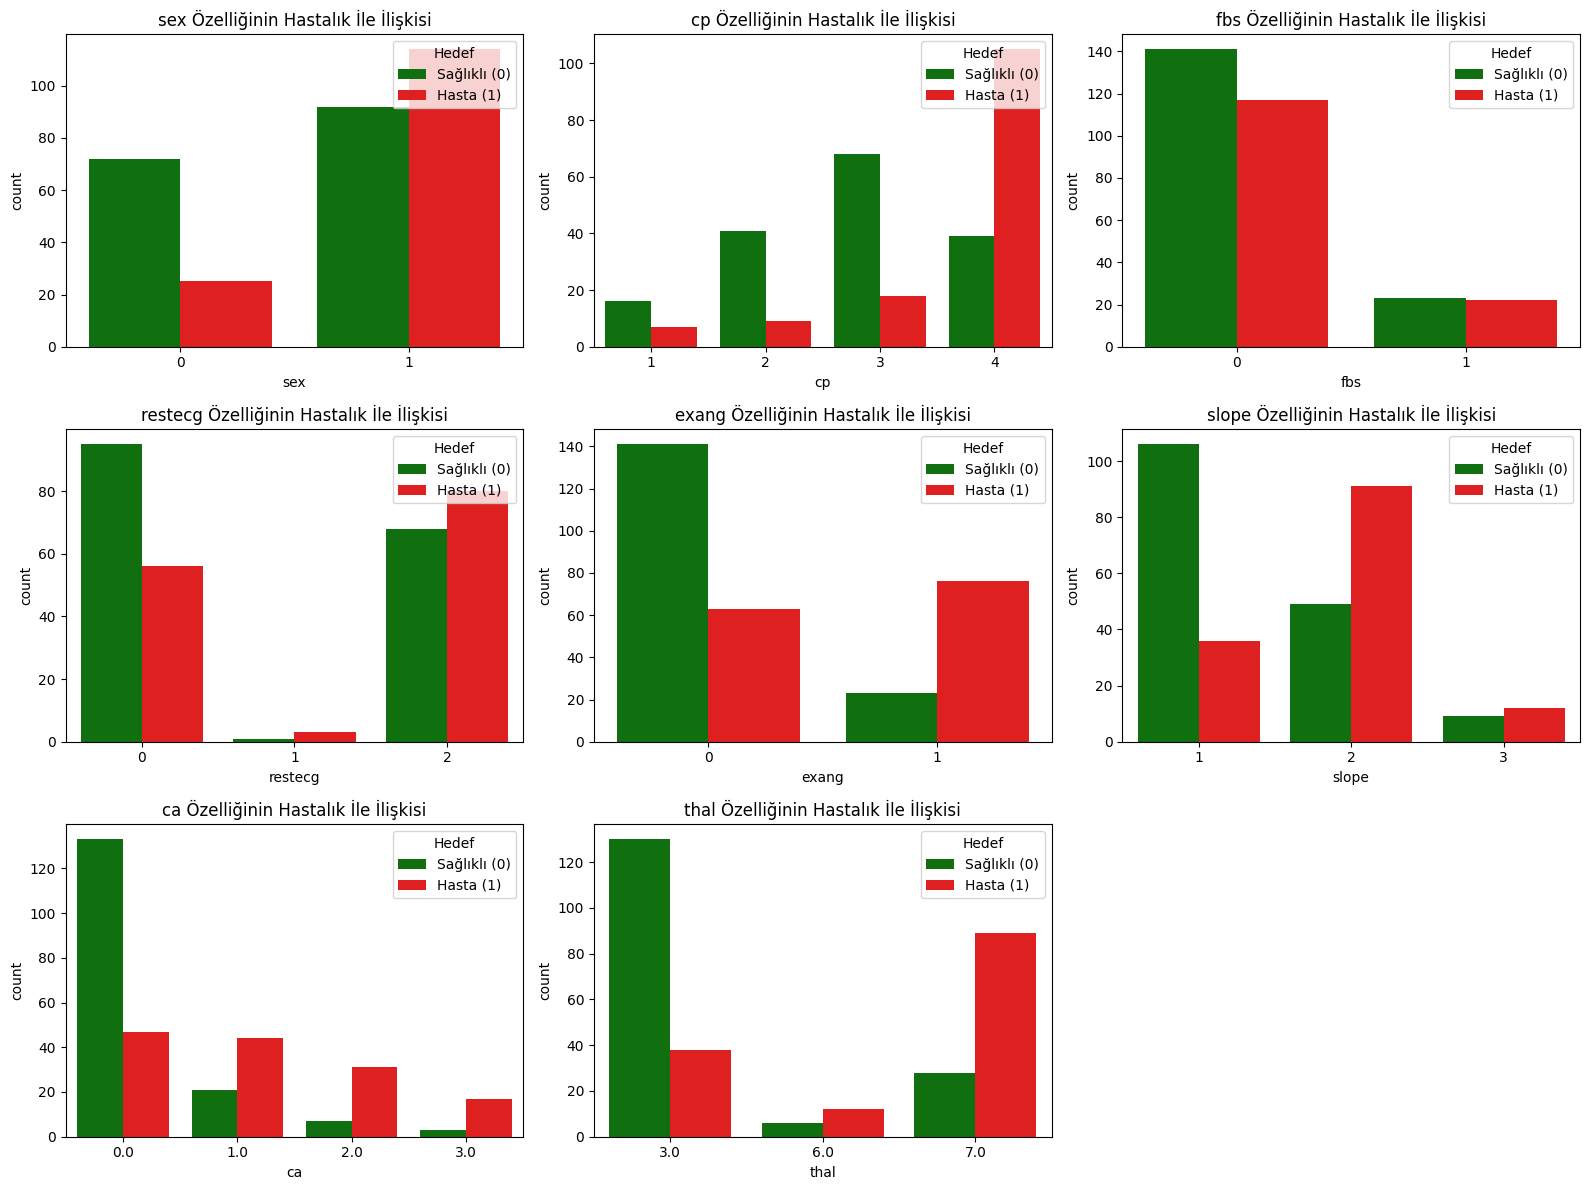

In [67]:
# Kategorik Değişkenler ve Hastalık Oranları (0: Sağlıklı=Yeşil, 1: Hasta=Kırmızı)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(
        data=df,
        x=col,
        hue='target',
        hue_order=[0, 1],
        palette=palette
    )
    plt.title(f'{col} Özelliğinin Hastalık İle İlişkisi')
    plt.legend(title='Hedef', labels=['Sağlıklı (0)', 'Hasta (1)'], loc='upper right')

plt.tight_layout()
plt.show()

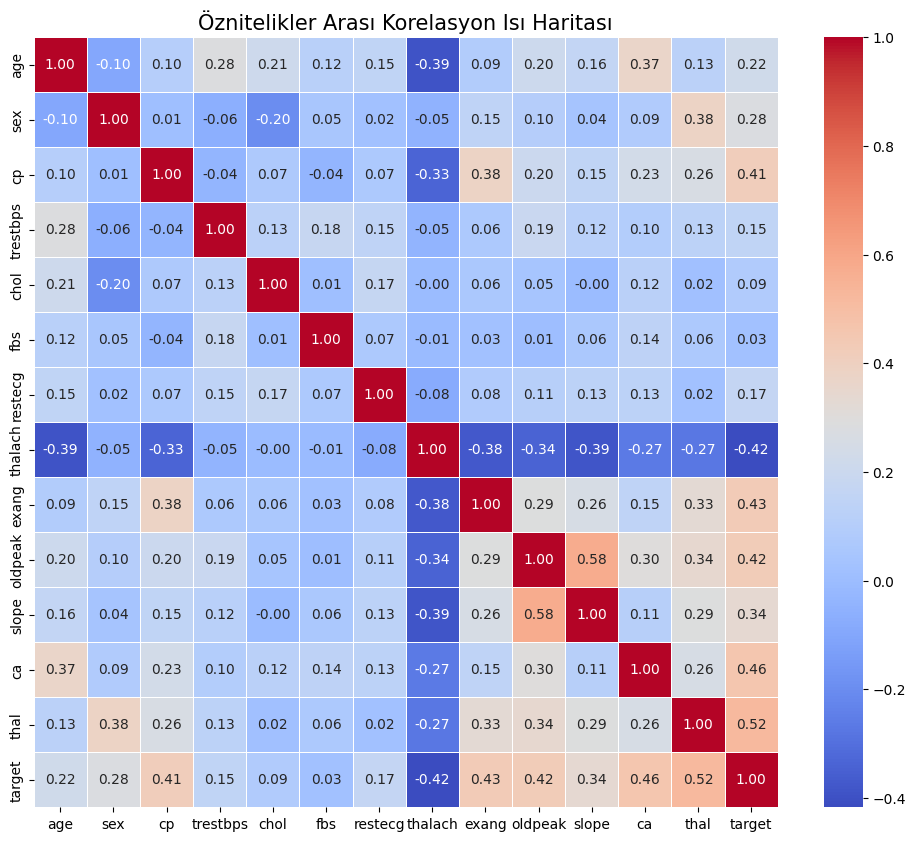

In [68]:
# Korelasyon
plt.figure(figsize=(12, 10))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Öznitelikler Arası Korelasyon Isı Haritası', fontsize=15)
plt.show()

# 5 Sınıflı Durum

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from ucimlrepo import fetch_ucirepo

In [70]:
warnings.filterwarnings('ignore')

In [ ]:
try:
    print("Veri API'den")
    heart_disease = fetch_ucirepo(id=45)
    X = heart_disease.data.features
    y = heart_disease.data.targets
    df5 = pd.concat([X, y], axis=1)

    if 'num' in df5.columns:
        df5.rename(columns={'num': 'diagnosis'}, inplace=True)
    print("Veri APIden yüklendi")
except Exception as e:
    print("API Hatası:", e)
    print("Veri lokalden yükleniyor")
    df5 = pd.read_csv('./data/heart_disease.csv')


Veri API'den çekiliyor...
API Hatası: Error connecting to server
Veri lokalden yükleniyor


In [72]:
df5

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [73]:
# 'ca' ve 'thal' kolonlarında '?' var, tam karar verilememiş ya da düzgün ölçülememiştir diye düşündüm ve NaN'a çevirip sayısal hale getirdim
if df5['ca'].dtype == 'object':
    df5['ca'] = pd.to_numeric(df5['ca'].replace('?', np.nan), errors='coerce')
if df5['thal'].dtype == 'object':
    df5['thal'] = pd.to_numeric(df5['thal'].replace('?', np.nan), errors='coerce')


# Tıbbi veri setlerinde en sık görülen değer genelde en güvenli tahminmiş o yüzden ortalama yerine mod tercih ettim
df5['ca'] = df5['ca'].fillna(df5['ca'].mode()[0])   
df5['thal'] = df5['thal'].fillna(df5['thal'].mode()[0])

# DİKKAT: Binarizasyon işlemi kaldırıldı!
# Hedef değişkeni doğrudan 'target' olarak kopyalıyoruz (Değerler: 0, 1, 2, 3, 4)
df5['target'] = df5['diagnosis']
df5.drop(columns=['diagnosis'], inplace=True)

print("\nEksik Veri (NaN) Sayıları:")
display(df5.isnull().sum())


Eksik Veri (NaN) Sayıları:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

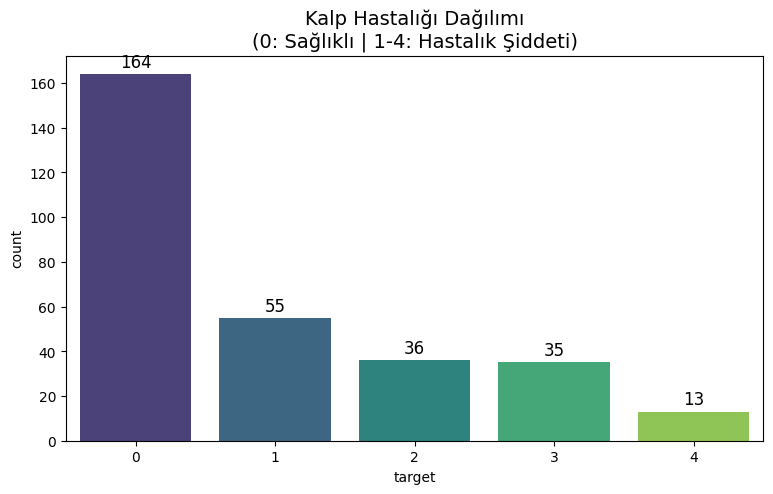

In [74]:
# Kalp Hastalığı Dağılımı (0-4)
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df5, x='target', palette='viridis')
plt.title('Kalp Hastalığı Dağılımı\n(0: Sağlıklı | 1-4: Hastalık Şiddeti)', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

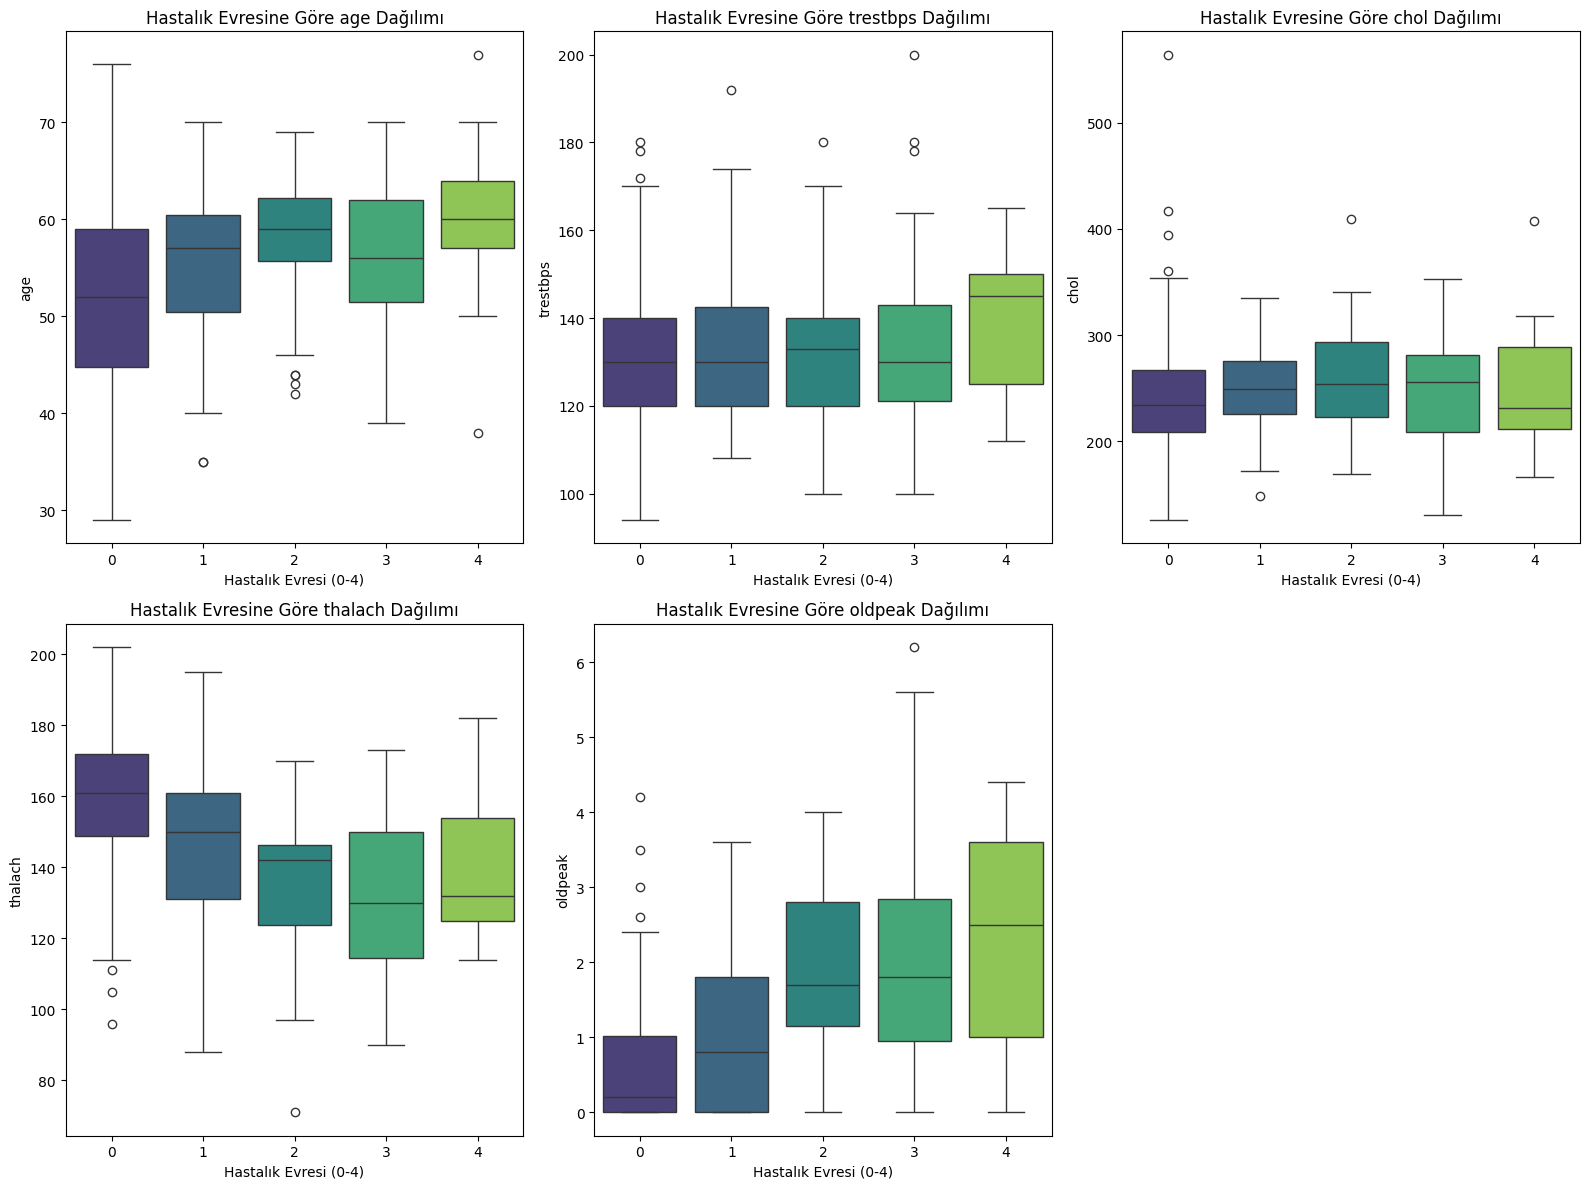

In [75]:
# Sayısal Değişkenlerin Hastalık Evresine Göre Değişimi
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target', y=col, data=df5, palette='viridis')
    plt.title(f'Hastalık Evresine Göre {col} Dağılımı')
    plt.xlabel('Hastalık Evresi (0-4)')
plt.tight_layout()
plt.show()

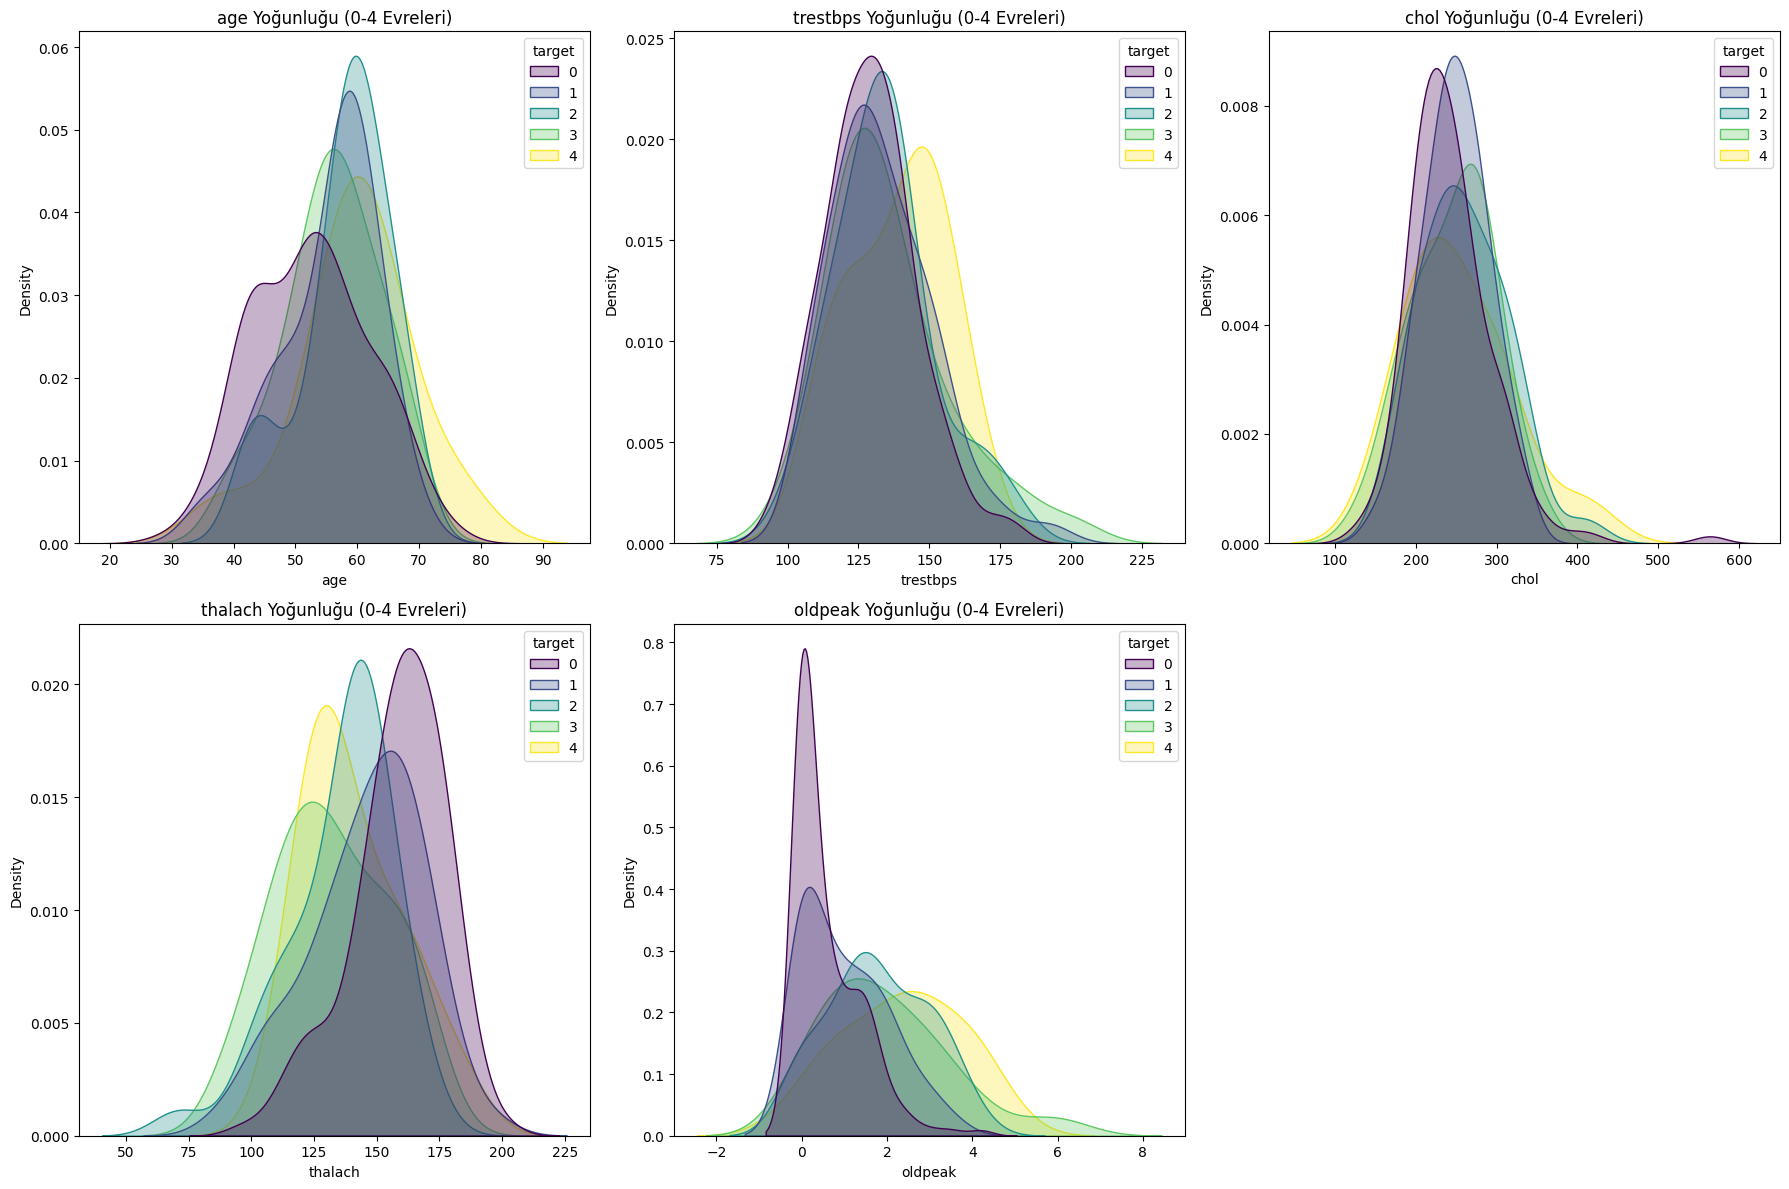

In [76]:
# Sayısal Değişkenlerin Yoğunluk (KDE) Dağılımları
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df5, x=col, hue='target', fill=True, common_norm=False, palette='viridis', alpha=0.3)
    plt.title(f'{col} Yoğunluğu (0-4 Evreleri)')
plt.tight_layout()
plt.show()

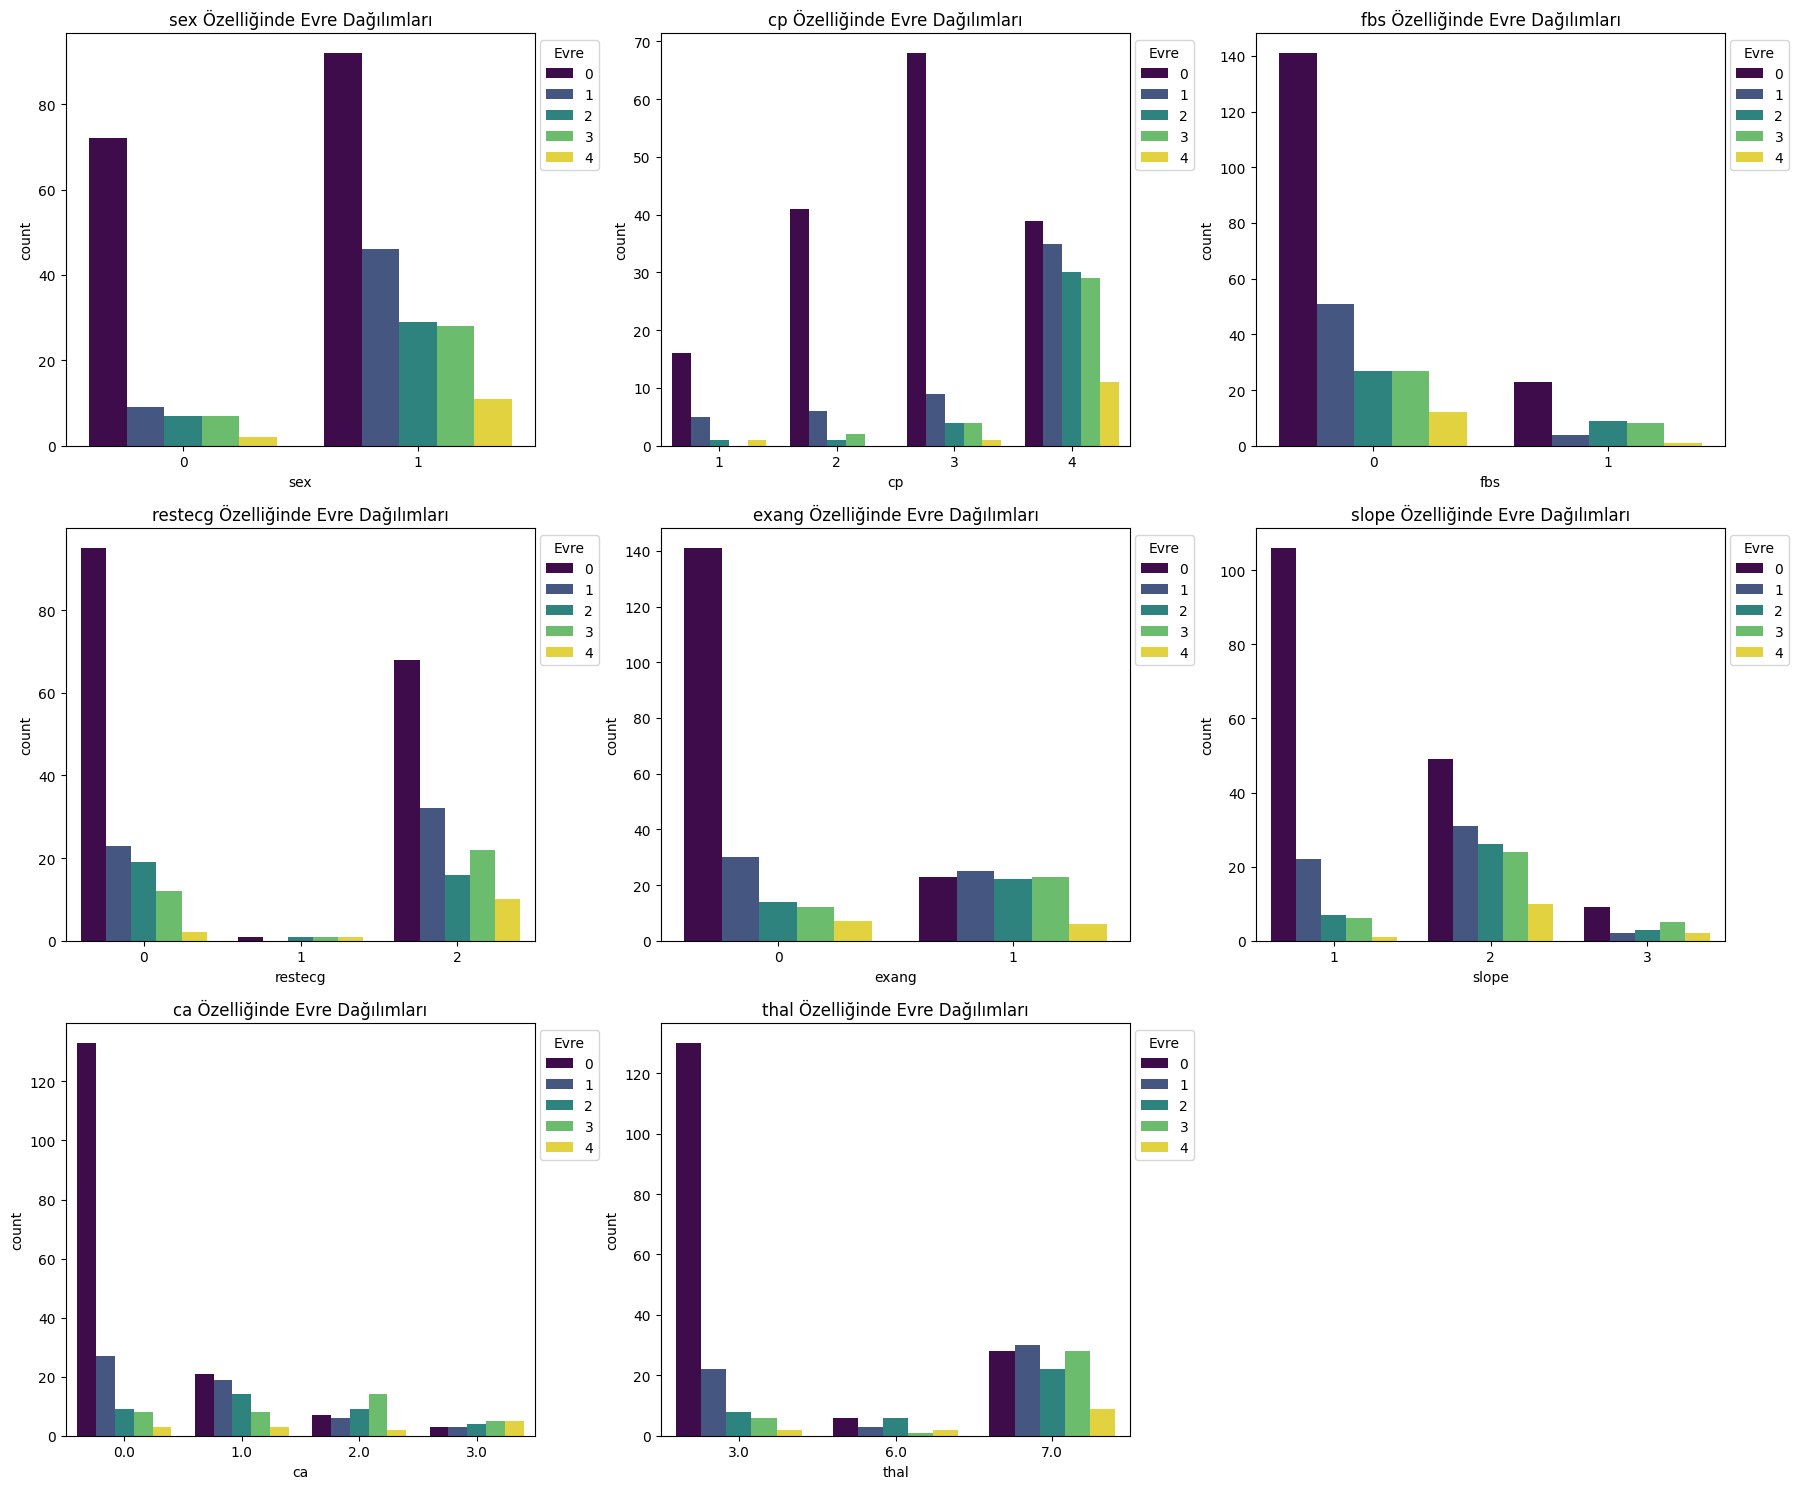

In [ ]:
# Kategorik Değişkenler ve Hastalık İlişkisi
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    
    sns.countplot(data=df5, x=col, hue='target', palette='viridis')
    plt.title(f'{col} Özelliğinde Evre Dağılımları')
    plt.legend(title='Evre', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

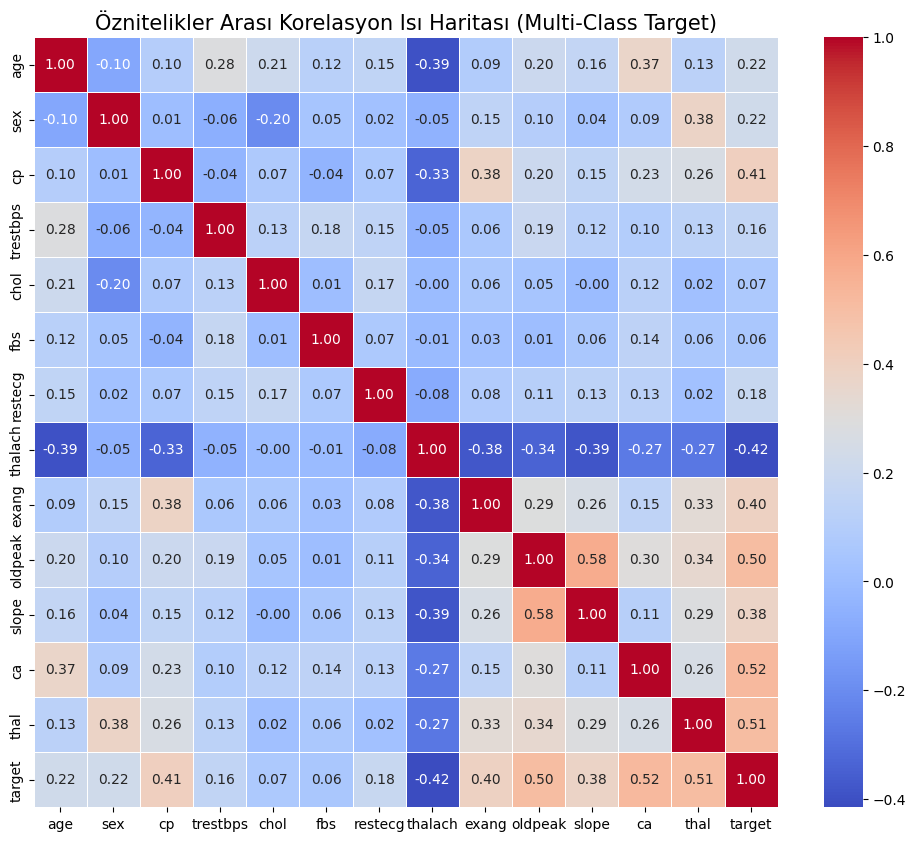

In [ ]:
# Korelasyon Matrisi
plt.figure(figsize=(12, 10))
corr = df5.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Öznitelikler Arası Korelasyon Isı Haritası (Multi-Class Target)', fontsize=15)
plt.show()